In [35]:
# importing libraries 
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style('whitegrid')

In [6]:
# loading data into python 
df = pd.read_csv(r"C:\Users\ENVY\OneDrive\Desktop\FOLDERS\python\fraud detection\banking_transactions.csv")

In [20]:
# normal analytics 

print("the size of your dataset is: ",df.shape)
df.info()
df.describe()

the size of your dataset is:  (10000, 20)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 20 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   transaction_id                  10000 non-null  int64  
 1   transaction_amount              10000 non-null  float64
 2   login_attempts                  10000 non-null  int64  
 3   device_risk_score               10000 non-null  float64
 4   transfer_frequency              10000 non-null  int64  
 5   anomaly_score                   10000 non-null  float64
 6   account_age_days                10000 non-null  int64  
 7   transaction_time_hour           10000 non-null  int64  
 8   failed_transactions_last_30d    10000 non-null  int64  
 9   avg_monthly_balance             10000 non-null  float64
 10  daily_transaction_count         10000 non-null  int64  
 11  geo_distance_km                 10000 non-null  int6

,transaction_id,transaction_amount,login_attempts,device_risk_score,transfer_frequency,anomaly_score,account_age_days,transaction_time_hour,failed_transactions_last_30d,avg_monthly_balance,daily_transaction_count,geo_distance_km,session_duration_minutes,transaction_velocity_score,card_present_flag,international_transaction_flag,suspicious_ip_flag
count,1.000000e+04,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000
mean,1.005000e+06,12412.754004,6.438900,50.257190,39.648400,0.348916,2510.240900,11.553600,12.437800,249367.527976,60.614300,7604.567500,60.479300,50.122240,0.492800,0.498400,0.500500
std,2.886896e+03,7200.700863,3.453558,29.414463,23.419868,0.236890,1436.335019,6.962254,7.532875,144580.006647,34.821533,4330.728784,34.833419,29.271512,0.499973,0.500022,0.500025
min,1.000001e+06,6.270000,1.000000,0.000000,0.000000,0.010000,6.000000,0.000000,0.000000,104.160000,1.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000
25%,1.002501e+06,6174.025000,3.000000,25.100000,19.000000,0.170000,1271.750000,6.000000,6.000000,122291.355000,30.750000,3896.000000,30.000000,24.800000,0.000000,0.000000,0.000000
50%,1.005000e+06,12322.965000,6.000000,50.200000,40.000000,0.310000,2511.000000,11.000000,13.000000,249799.800000,60.000000,7645.000000,61.000000,50.150000,0.000000,0.000000,1.000000
75%,1.007500e+06,18619.650000,9.000000,75.500000,60.000000,0.480000,3746.250000,18.000000,19.000000,373146.842500,91.000000,11376.250000,91.000000,75.400000,1.000000,1.000000,1.000000
max,1.010000e+06,24997.520000,12.000000,100.000000,80.000000,0.990000,5000.000000,23.000000,25.000000,499968.250000,120.000000,14997.000000,120.000000,100.000000,1.000000,1.000000,1.000000


missing values in each column
transaction_id                    0
transaction_amount                0
login_attempts                    0
device_risk_score                 0
transfer_frequency                0
anomaly_score                     0
account_age_days                  0
transaction_time_hour             0
failed_transactions_last_30d      0
avg_monthly_balance               0
daily_transaction_count           0
geo_distance_km                   0
session_duration_minutes          0
transaction_velocity_score        0
payment_channel                   0
authentication_type               0
card_present_flag                 0
international_transaction_flag    0
suspicious_ip_flag                0
fraud_flag                        0
dtype: int64
number of duplicate entries:  0


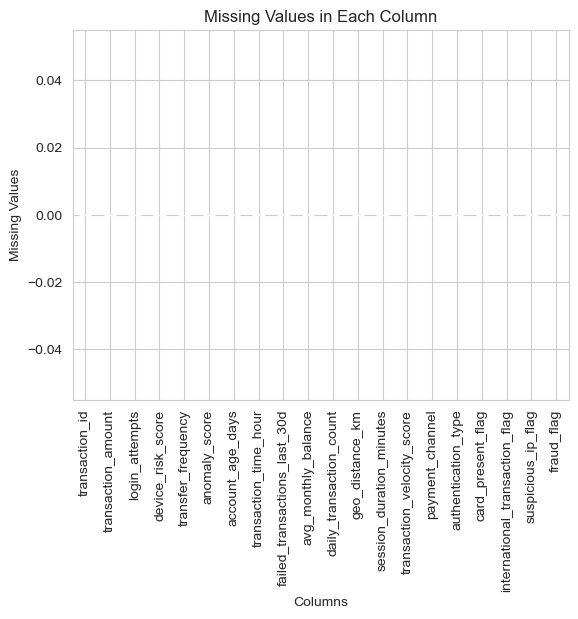

<function matplotlib.pyplot.show(close=None, block=None)>

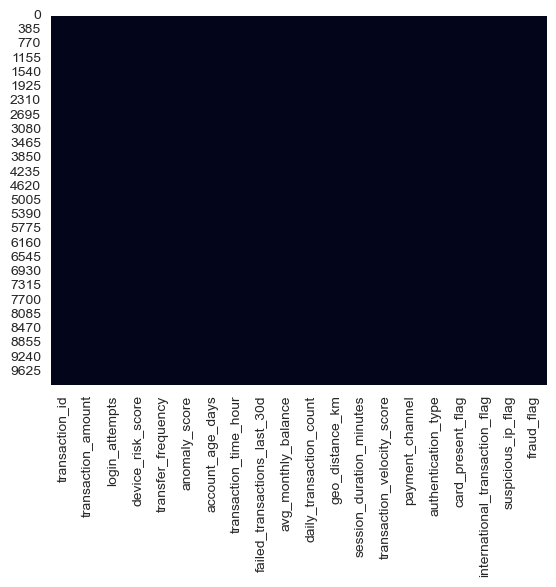

In [45]:
# check if there are missing values or duplicate values 
print("missing values in each column")
print(df.isnull().sum())
print("number of duplicate entries: ",df.duplicated().sum())

# visualising missing values 

# bar chart 
df.isnull().sum().plot(kind='bar')
plt.xlabel("Columns")
plt.ylabel("Missing Values")
plt.title("Missing Values in Each Column")
plt.show()

# heatmap
sns.heatmap(df.isnull(), cbar=False)
plt.show


# if there were any missing values we can drop them by adding df = df.drop_duplicates().



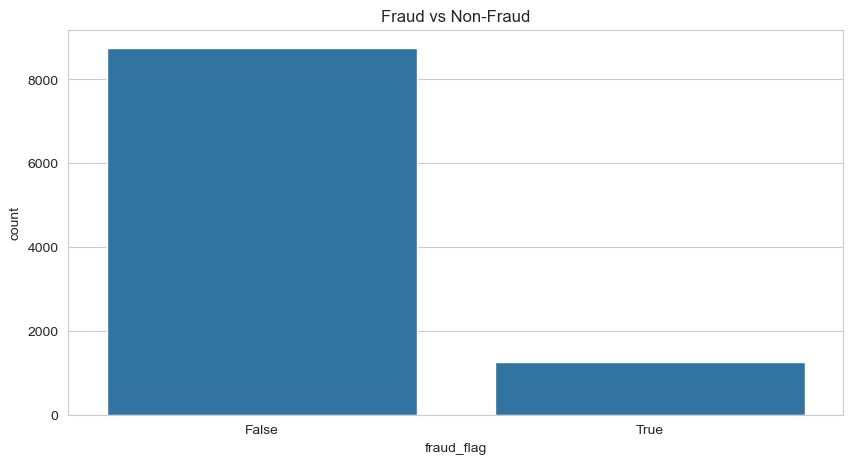

fraud_flag
False    87.49
True     12.51
Name: proportion, dtype: float64

In [65]:
# fraud vs non fraud graph
plt.figure(figsize=(10,5))

sns.countplot(x='fraud_flag', data=df)

plt.title("Fraud vs Non-Fraud")

plt.show()

# proportion of Fraud vs Non-Fraud
df['fraud_flag'].value_counts(normalize=True) * 100

In [61]:
# Univariate Analysis

# df.hist(figsize=(15,12), bins=30)
# plt.show()

# sns.boxplot(x=df['transaction_amount'])
# plt.show()

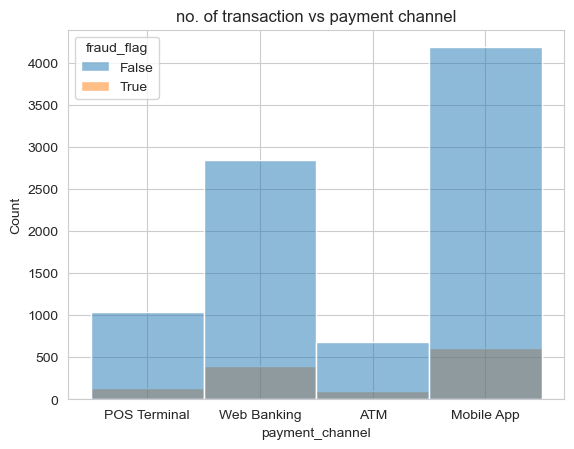

In [87]:
sns.histplot(x='payment_channel',hue='fraud_flag', data=df)
plt.title("no. of transaction vs payment channel")
plt.xticks(rotation=0)
plt.show()

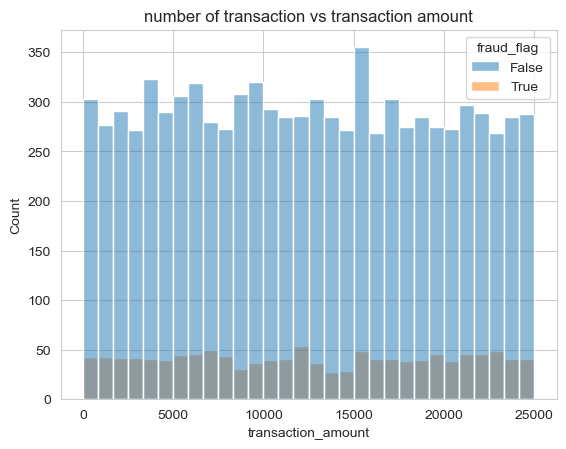

In [72]:
sns.histplot(data=df, x='transaction_amount', hue='fraud_flag', bins=30)
plt.title("number of transaction vs transaction amount")
plt.show()

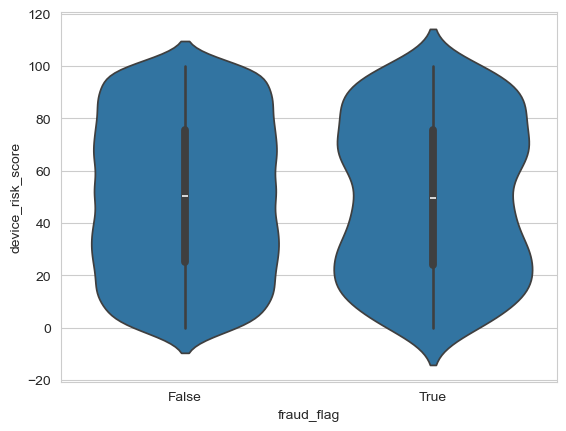

In [74]:
sns.violinplot(x='fraud_flag', y='device_risk_score', data=df)
plt.show()

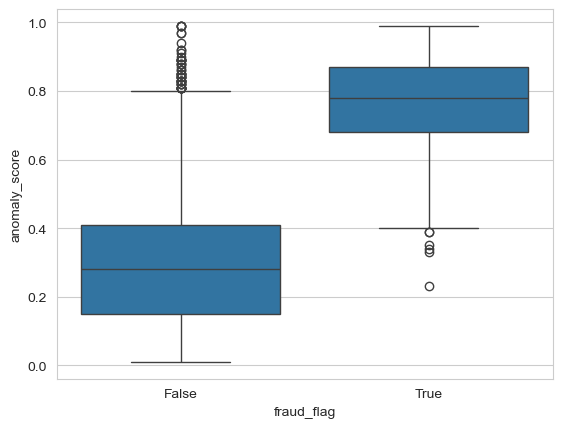

In [76]:
sns.boxplot( x='fraud_flag', y='anomaly_score', data=df)
plt.show()


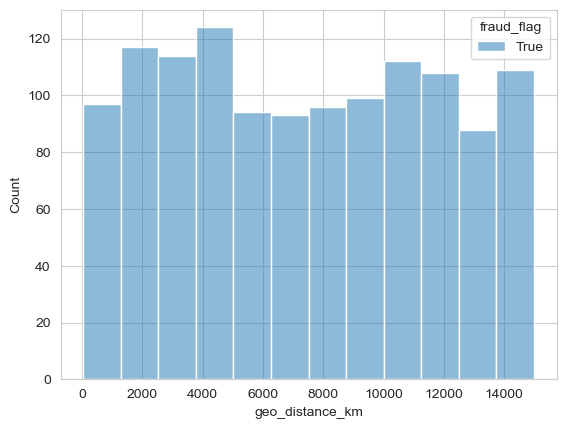

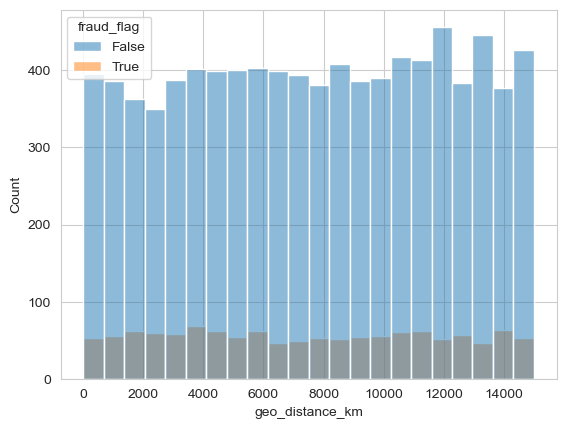

In [84]:
fraud = df[df['fraud_flag'] == True]

sns.histplot( hue='fraud_flag', x='geo_distance_km', data=fraud)
plt.show()

sns.histplot( hue='fraud_flag', x='geo_distance_km', data=df)
plt.show()

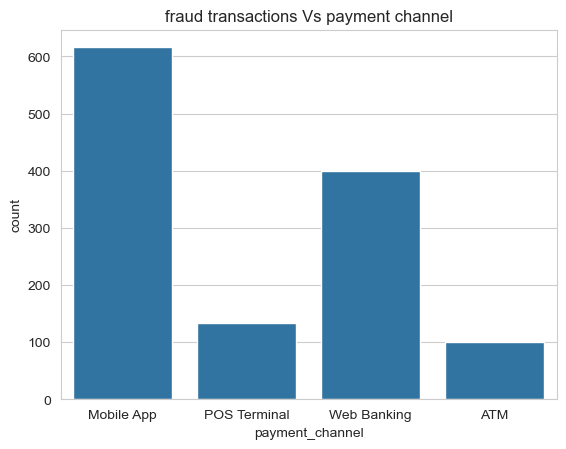

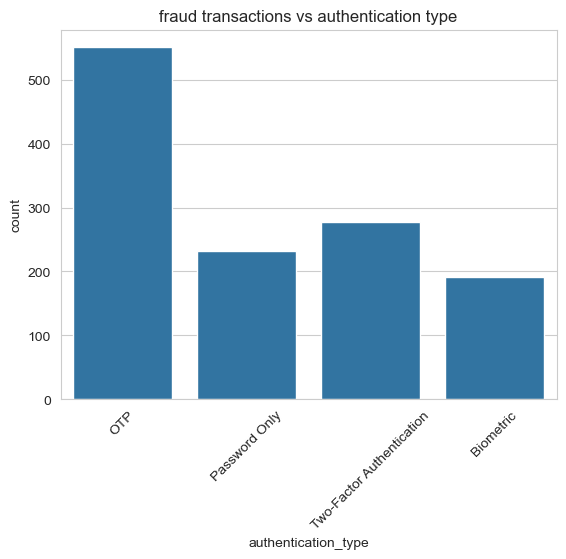

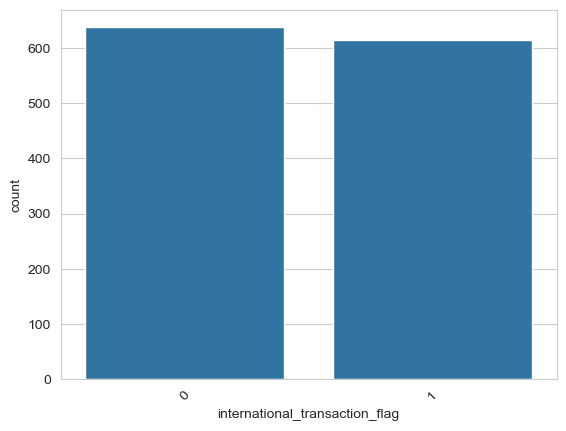

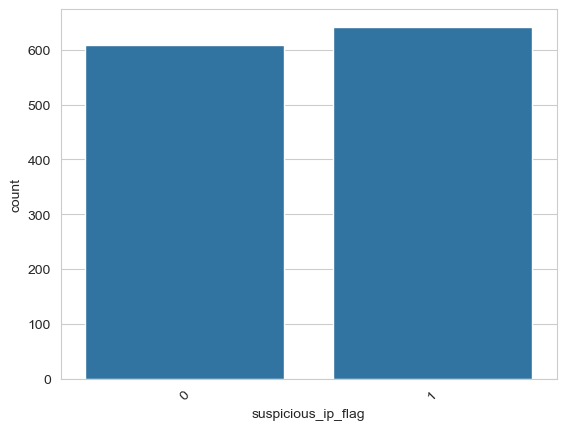

In [95]:
sns.countplot(x='payment_channel', data=fraud)
plt.title('fraud transactions Vs payment channel')
plt.show()

sns.countplot(x='authentication_type', data=fraud)
plt.title('fraud transactions vs authentication type')
plt.xticks(rotation=45)
plt.show()


sns.countplot(x='international_transaction_flag', data=fraud)
plt.xticks(rotation=45)
plt.show()

sns.countplot(x='suspicious_ip_flag', data=fraud)
plt.xticks(rotation=45)
plt.show()

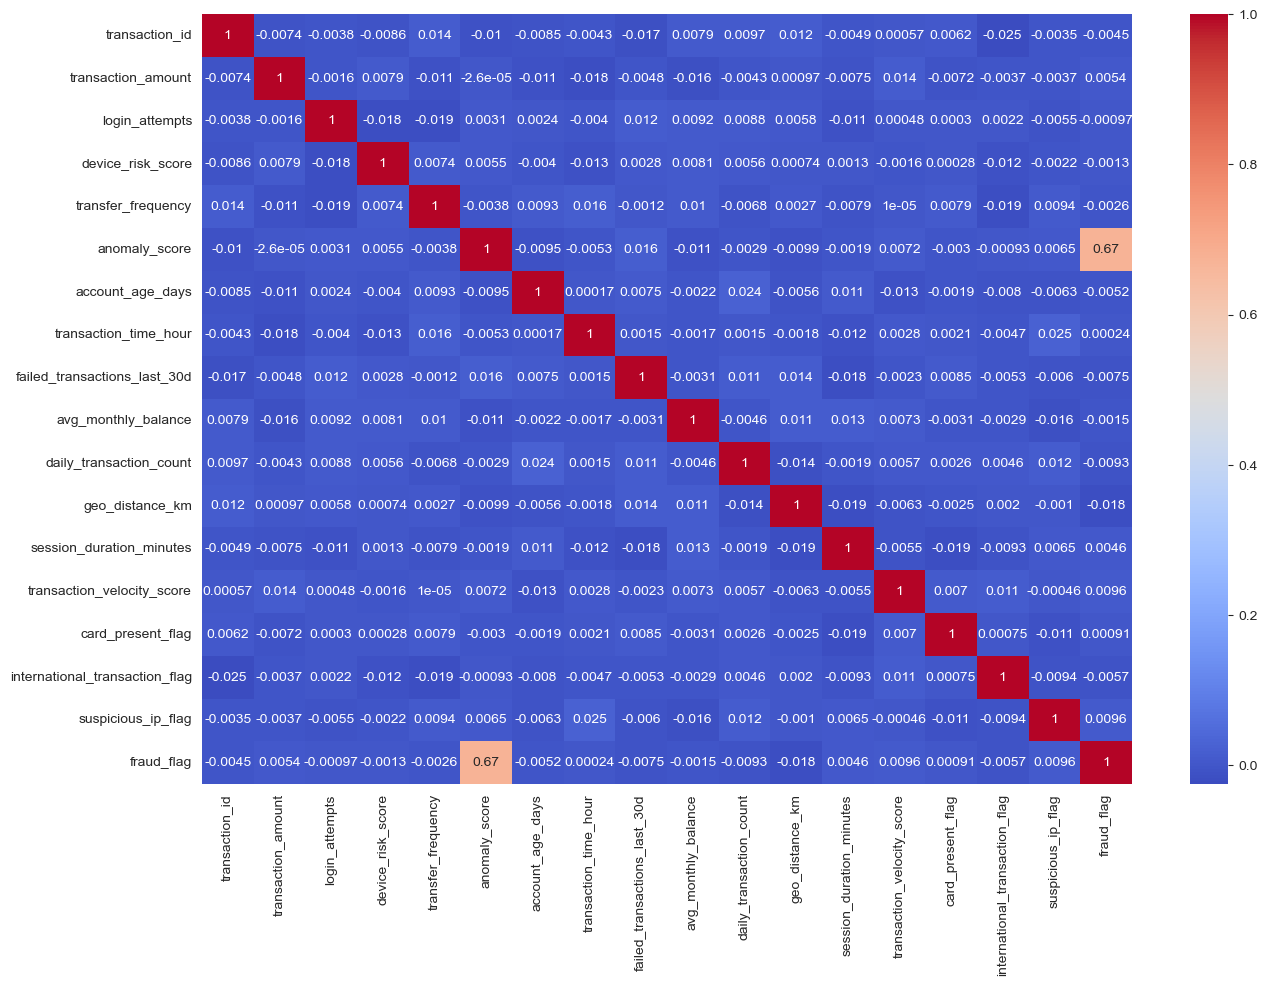

In [97]:
corr = df.corr(numeric_only=True)

plt.figure(figsize=(15,10))
sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.show()

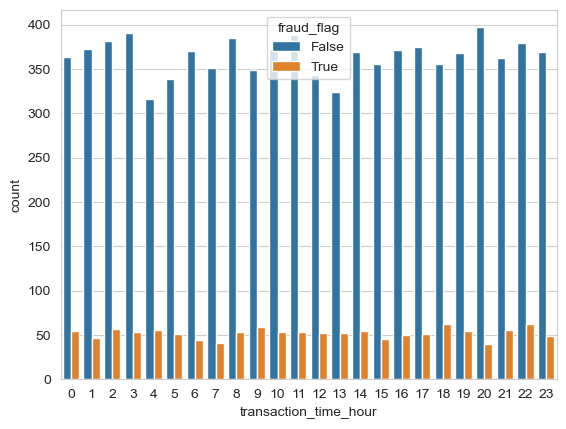

In [99]:
sns.countplot(x='transaction_time_hour',
              hue='fraud_flag',
              data=df)
plt.show()

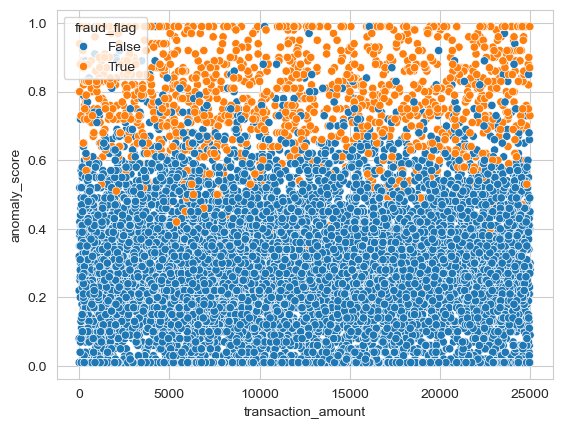

In [101]:
sns.scatterplot(x='transaction_amount',
                y='anomaly_score',
                hue='fraud_flag',
                data=df)
plt.show()

In [103]:
# outlier detection

Q1 = df['transaction_amount'].quantile(0.25)
Q3 = df['transaction_amount'].quantile(0.75)

IQR = Q3 - Q1

outliers = df[
    (df['transaction_amount'] < Q1 - 1.5*IQR) |
    (df['transaction_amount'] > Q3 + 1.5*IQR)
]

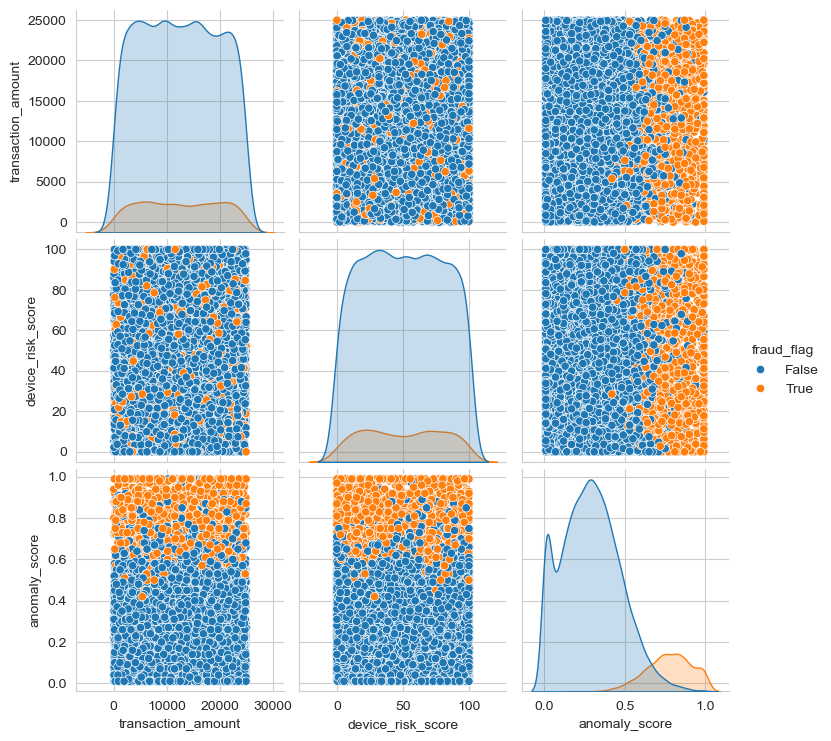

In [106]:
sns.pairplot(df[['transaction_amount',
                 'device_risk_score',
                 'anomaly_score',
                 'fraud_flag']],
             hue='fraud_flag')
plt.show()